In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import zscore
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from scipy.stats import linregress
from matplotlib.colors import PowerNorm
import seaborn as sns

from MyLovelyFunctions import *

In [4]:
import sys
sys.path.insert(1, '../ProcessEvents')
from config import CATCHMENTS

In [5]:
region_order = ["North Scotland","East Scotland","West Scotland","North West England","North East England",
                "Yorkshire and Humber","West Midlands","East Midlands","East of England","Wales",
                "South West England","South East England","London"]

## ------------------------------------------------------------ ###
### Get rainfall events
    And add extra variables
## ------------------------------------------------------------ ###

In [6]:
fp = f"/scratch/hydro4/users/kv25483/FutureFlood/Data/EventDetails/all_catchments_added_soilvars_and_othervars.pkl"
rainfall_events_all_df = pd.read_pickle(fp)
rainfall_events_all_df = rainfall_events_all_df[rainfall_events_all_df['max_precip']<130].copy()
rainfall_events_all_df = rainfall_events_all_df[rainfall_events_all_df['start_year']>1991].copy()
rainfall_events_all_df["length"] = (rainfall_events_all_df["stop_idx"] - rainfall_events_all_df["start_idx"]).astype("float32")
# print(len(rainfall_events_all_df))
# rainfall_events_all_df = rainfall_events_all_df[rainfall_events_all_df['length']>10].copy()
# print(len(rainfall_events_all_df))
len(np.unique(rainfall_events_all_df['catchment_num']))

rainfall_events_all_df['fu_at_peak_mm'] = rainfall_events_all_df['fu_at_peak']*1000

rainfall_events_all_df['HC_status'] = pd.cut(rainfall_events_all_df['hc_at_peak'],
    bins=[-float('inf'), 0.15, 1.1, 3, float('inf')],labels=['D', 'C', 'B', 'A'], right=False, include_lowest=True)

In [7]:
# plt.scatter(rainfall_events_all_df['hc_at_peak'], rainfall_events_all_df['fumax_at_peak'])

In [8]:
# sat_events = rainfall_events_all_df[rainfall_events_all_df['fu_at_peak_mm'] == 0.]
# plt.scatter(sat_events['10cm_area'], sat_events['total_acc'])

In [9]:
# rainfall_events_all_df.sort_values(by='length', ascending=False)[['ens', 'catchment_num', 'event_num', 'max_precip']][:20]

## ------------------------------------------------------------ ###
### Create annual summaries of rainfall and flood severity
    And rolling summaries
## ------------------------------------------------------------ ###

In [10]:
annual_mean_flood_severity = (rainfall_events_all_df.groupby("start_year", observed=True)["10cm_area"].mean())
annual_mean_rainfall_intensity = (rainfall_events_all_df.groupby("start_year", observed=True)["max_precip"].mean())
annual_mean_rainfall_accum = (rainfall_events_all_df.groupby("start_year", observed=True)["total_acc"].mean())
annual_counts = (rainfall_events_all_df.groupby(["start_year"],observed=True)).size()
annual_severity = (rainfall_events_all_df.groupby(["start_year"], observed=True)["10cm_area"].sum())

In [11]:
rolling_annual_counts =annual_counts.rolling(window=10,center=True, min_periods=5).mean()
rolling_flood_severity =annual_mean_flood_severity.rolling(window=10,center=True, min_periods=5).mean()
rolling_rainfall_intensity =annual_mean_rainfall_intensity.rolling(window=10,center=True, min_periods=5).mean()
rolling_rainfall_accumulation =annual_mean_rainfall_accum.rolling(window=10,center=True, min_periods=5).mean()

## ------------------------------------------------------------ ###
### Get spatial data and add regional geometries to rainfall data
## ------------------------------------------------------------ ###

In [12]:
regions_shp = "/scratch/hydro5/users/la17355/FUTURE-FLOOD/Results/Pluvial/v4/#ss/plots/most_exposed_events_visualisation/by_region/ukcp18-uk-land-region-hires.shp"
regions_df = gpd.read_file(regions_shp)
regions_df["region_geometry"] = regions_df.geometry

catchments_df = CATCHMENTS
catchments_df["catchment_geometry"] = catchments_df.geometry

# Event points
rainfall_events_all_df = gpd.GeoDataFrame(rainfall_events_all_df,
                        geometry=gpd.points_from_xy(rainfall_events_all_df["x_coord"], rainfall_events_all_df["y_coord"]), 
                                          crs=regions_df.crs)

# Remove old sjoin columns if this dataframe has been joined before
rainfall_events_all_df = rainfall_events_all_df.drop(
    columns=["index_right", "geo_region", "region_geometry", "HA_NAME", "catchment_geometry"], errors="ignore")

# Join regions
rainfall_events_all_df = gpd.sjoin(rainfall_events_all_df, regions_df[["geo_region", "region_geometry", "geometry"]],
    how="left", predicate="within")

# Drop index_right before the next sjoin, or geopandas will error on the clash
rainfall_events_all_df = rainfall_events_all_df.drop(columns=["index_right"], errors="ignore")

# Join catchments
rainfall_events_all_df = gpd.sjoin(rainfall_events_all_df, catchments_df[["HA_NAME", "catchment_geometry", "geometry"]],
    how="left", predicate="within")

rainfall_events_all_df = rainfall_events_all_df.drop(columns=["index_right"], errors="ignore")

## ------------------------------------------------------------ ###
### Add column defining which of 3 temporal periods an event is within
## ------------------------------------------------------------ ###

In [13]:
conditions = [rainfall_events_all_df["start_year"].between(1990, 2020),rainfall_events_all_df["start_year"].between(2020, 2050),
    rainfall_events_all_df["start_year"].between(2050, 2080),]
choices = ["1990–2020", "2020–2050", "2050–2080"]

rainfall_events_all_df["period"] = np.select(conditions, choices, default=None)

In [14]:
rainfall_events_all_df.columns

Index(['max_precip', 't_global', 't_local', 'x_idx', 'y_idx', 'x_idx_global',
       'y_idx_global', 'x_coord', 'y_coord', 'ens',
       ...
       'urban_prop', 'inside_prop', 'fu_at_peak_mm', 'HC_status', 'geometry',
       'geo_region', 'region_geometry', 'HA_NAME', 'catchment_geometry',
       'period'],
      dtype='object', length=116)

</div>

<div style="background-color: lightblue; border: 1px solid black; border-radius: 5px; padding: 15px 20px; margin: 10px 0px;">

## Spatial plots of regional changes between beginning and end of simulatin


</div>

In [15]:
variables = ["max_precip","total_acc","10cm_area", "sat_at_peak", "lu_at_peak", "fu_at_peak", 'mean_sm_2_before_event',
       'length']
catchment_summary = regional_period_summary(rainfall_events_all_df,variables, 'catchment_geometry')
catchment_summary_gdf = gpd.GeoDataFrame(summary,geometry="catchment_geometry",crs=regions_df.crs)

NameError: name 'summary' is not defined

In [ ]:
# regional_summary = regional_period_summary(rainfall_events_all_df,variables, 'region_geometry')
regional_summary_gdf = regional_summary.merge(regions_df[["geo_region", "region_geometry"]],on="region_geometry",how="left")
regional_summary_gdf = gpd.GeoDataFrame(regional_summary_gdf,geometry="region_geometry",crs=regions_df.crs)

In [ ]:
make_spatial_change_plot(regional_summary_gdf, "length", "length", 'Hours', '1990_2020', '2020_2050')

In [ ]:
make_spatial_change_plot(regional_summary_gdf, "n_events", "Num events", 'n', '1990_2020', '2050_2080')
make_spatial_change_plot(regional_summary_gdf, "10cm_area", "Flooded area", 'km', '1990_2020', '2050_2080')

In [ ]:
summary_HC = regional_period_summary(rainfall_events_all_df,variables, 'HC_status')
make_HC_change_plot(summary_HC, "n_events","Num events");
make_HC_change_plot(summary_HC, "10cm_area","Flooded area");

</div>

<div style="background-color: lightblue; border: 1px solid black; border-radius: 5px; padding: 15px 20px; margin: 10px 0px;">

## Flood severity per intensity bin, in each region

</div>

In [ ]:
rainfall_events_all_df["intensity_bin"] = pd.cut(rainfall_events_all_df["max_precip"],bins=[30, 40, 50, 75, 100],
    labels=["30–40", "40–50", "50–75", "75–100"])

summary = (rainfall_events_all_df.groupby(["geo_region", "intensity_bin"], observed=True)["10cm_area"].mean().unstack())

colors = plt.cm.viridis(np.linspace(0, 1, 13))

# Your plot currently reverses the region order, so make the same mapping
region_colors = dict(zip(reversed(region_order), colors))

fig, (ax, ax_map) = plt.subplots(1, 2, figsize=(15, 10))

# -------------------------
# LEFT: rainfall plot
# -------------------------

for region, color in zip(reversed(region_order), colors):
    ax.plot(summary.columns,summary.loc[region],marker="o",linewidth=3,markersize=5,color=color,label=region)

ax.set_xlabel("Maximum rainfall intensity (mm/hr)", fontsize=18)
ax.set_ylabel("Mean area flooded >10 cm", fontsize=18)
ax.set_title("Mean per-event flooded area across intensity bins",
             fontsize=20, pad=12)

ax.grid(axis="y", alpha=0.25)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.tick_params(axis="both", which="major", labelsize=12)

ax.legend(title="Region",bbox_to_anchor=(1.02, 0.5),loc="center left",frameon=False,fontsize=15)

# -------------------------
# RIGHT: regional map
# -------------------------

rainfall_events_all_df.plot(ax=ax_map,color=rainfall_events_all_df["geo_region"].map(region_colors),edgecolor="black"
                            ,linewidth=0.7)

ax_map.set_title("Regions", fontsize=20, pad=12)
ax_map.set_axis_off()

fig.tight_layout()
plt.show()

In [ ]:
def plot_depth_by_intensity_for_timeslices(df):

    binned = (df.groupby(["geo_region", "period", "intensity_bin"],observed=True)["10cm_area"].agg(["mean", "median", "count"])
              .reset_index())

    ### Set colors
    colors = plt.cm.plasma(np.linspace(0, 1, 3))
    timeperiod_colors = dict(zip(reversed(np.unique(df['period'])), colors))

    # fig, axes = plt.subplots(nrows=int(np.ceil(len(region_order) / 3)),ncols=3,figsize=(15, 4 * int(np.ceil(len(region_order) / 3))))
    fig, axes = plt.subplots(5, 3, figsize=(12, 15), sharex=True, sharey=False)
    axes = axes.flatten()

    for ax, region in zip(axes, region_order):

        df = binned[binned["geo_region"] == region]

        for period, group in df.groupby("period",observed=False):

            ax.plot(group["intensity_bin"].astype(str),group["mean"],marker="o",label=period, color = timeperiod_colors[period])

        # ax.set_xlabel("Maximum precipitation")
        ax.set_ylabel("Mean 10cm area")
        ax.set_title(region)

        ax.legend()
        ax.tick_params(labelrotation=45)

    for j in range(len(region_order), 5 * 3):
        axes[j].axis("off")

    fig.suptitle("Changes to Mean per-event flooded area across intensity bins in the future climate");
    fig.tight_layout();
    
short_events = rainfall_events_all_df[rainfall_events_all_df['length']<12]    
# plot_depth_by_intensity_for_timeslices(short_events)    
# plt.hist(rainfall_events_all_df['length'], bins=50)

In [ ]:
# import glob
# current_min = 10
# for file in glob.glob("/scratch/hydro4/users/la17355/FUTURE-FLOOD/UKCP_rainfall_events/fixed_threshold_30mm_with_volume/*"):
#     file = pd.read_csv(file)
#     if min(file['event_durations']) < current_min:
#         current_min = min(file['event_durations'])
#         print(current_min)
# len(glob.glob("/scratch/hydro4/users/la17355/FUTURE-FLOOD/UKCP_rainfall_events/fixed_threshold_30mm_with_volume/*"))

</div>

<div style="background-color: lightblue; border: 1px solid black; border-radius: 5px; padding: 15px 20px; margin: 10px 0px;">

## Strength of correlation between flood and rainfall, in each region

</div>

In [ ]:
import statsmodels.formula.api as smf
from scipy.stats import linregress

fig, axs = plt.subplots(5, 3, figsize=(12, 15), sharex=True, sharey=False)
axs = axs.flatten()

for i, hc in enumerate(region_order):

    subset = rainfall_events_all_df[
        rainfall_events_all_df["geo_region"] == hc].dropna(subset=["max_precip", "10cm_area", "hc_at_peak"])

    n_events = len(subset)

    x = subset["max_precip"]
    y = subset["10cm_area"]

    # Simple regression: flood area ~ rainfall intensity
    slope, intercept, r_value, p_value, std_err = linregress(x, y)
    r2_simple = r_value**2
    if p_value <0.005:
        p_value = '<0.05'

    x_line = np.linspace(x.min(), x.max(), 100)
    y_line = intercept + slope * x_line

    # Multiple regression: flood area ~ rainfall intensity + HC
    model = smf.ols( "Q('10cm_area') ~ max_precip + hc_at_peak",data=subset).fit()

    r2_multiple = model.rsquared
    p_hc = model.pvalues["hc_at_peak"]
    if p_hc <0.005:
        p_hc = '<0.05'
    
    # Multiple regression: flood area ~ rainfall intensity + HC
    model3 = smf.ols( "Q('10cm_area') ~ max_precip + hc_at_peak + fu_at_peak_mm",data=subset).fit()

    r2_model3 = model3.rsquared
    p_model3 = model3.pvalues["hc_at_peak"]
    if p_model3 <0.005:
        p_model3 = '<0.05'
    
    # Plot
    axs[i].scatter(x, y, alpha=0.25, s=15)
    axs[i].plot(x_line, y_line, linewidth=2)

    axs[i].set_title(hc, fontsize=15, pad=8)

    axs[i].text(
        0.05, 0.92,
        f"n = {n_events}\n"
        f"Rainfall only:\n"
        f"$R^2$ = {r2_simple:.2f}, p {p_value}\n"
        f"Rainfall + HC:\n"
        f"$R^2$ = {r2_multiple:.2f}, p {p_hc}\n"
        f"Rainfall + HC _ FU:\n"
        f"$R^2$ = {r2_model3:.2f}, p {p_model3}\n"
        f"n = {n_events}", transform=axs[i].transAxes, va="top", fontsize=11)

    axs[i].grid(alpha=0.2)
    axs[i].tick_params(axis="both", which="major", labelsize=15)

    if i % 3 == 0:
        axs[i].set_ylabel("Flooded area\n>10 cm", fontsize=15)
    else:
        axs[i].set_ylabel("")

    if i >= 12:
        axs[i].set_xlabel("Maximum rainfall intensity (mm/hr)", fontsize=15)
    else:
        axs[i].set_xlabel("")

for j in range(len(region_order), 5 * 3):
    axs[j].axis("off")

fig.tight_layout(h_pad=1.5, w_pad=1.2)
plt.show()

### Split by time period

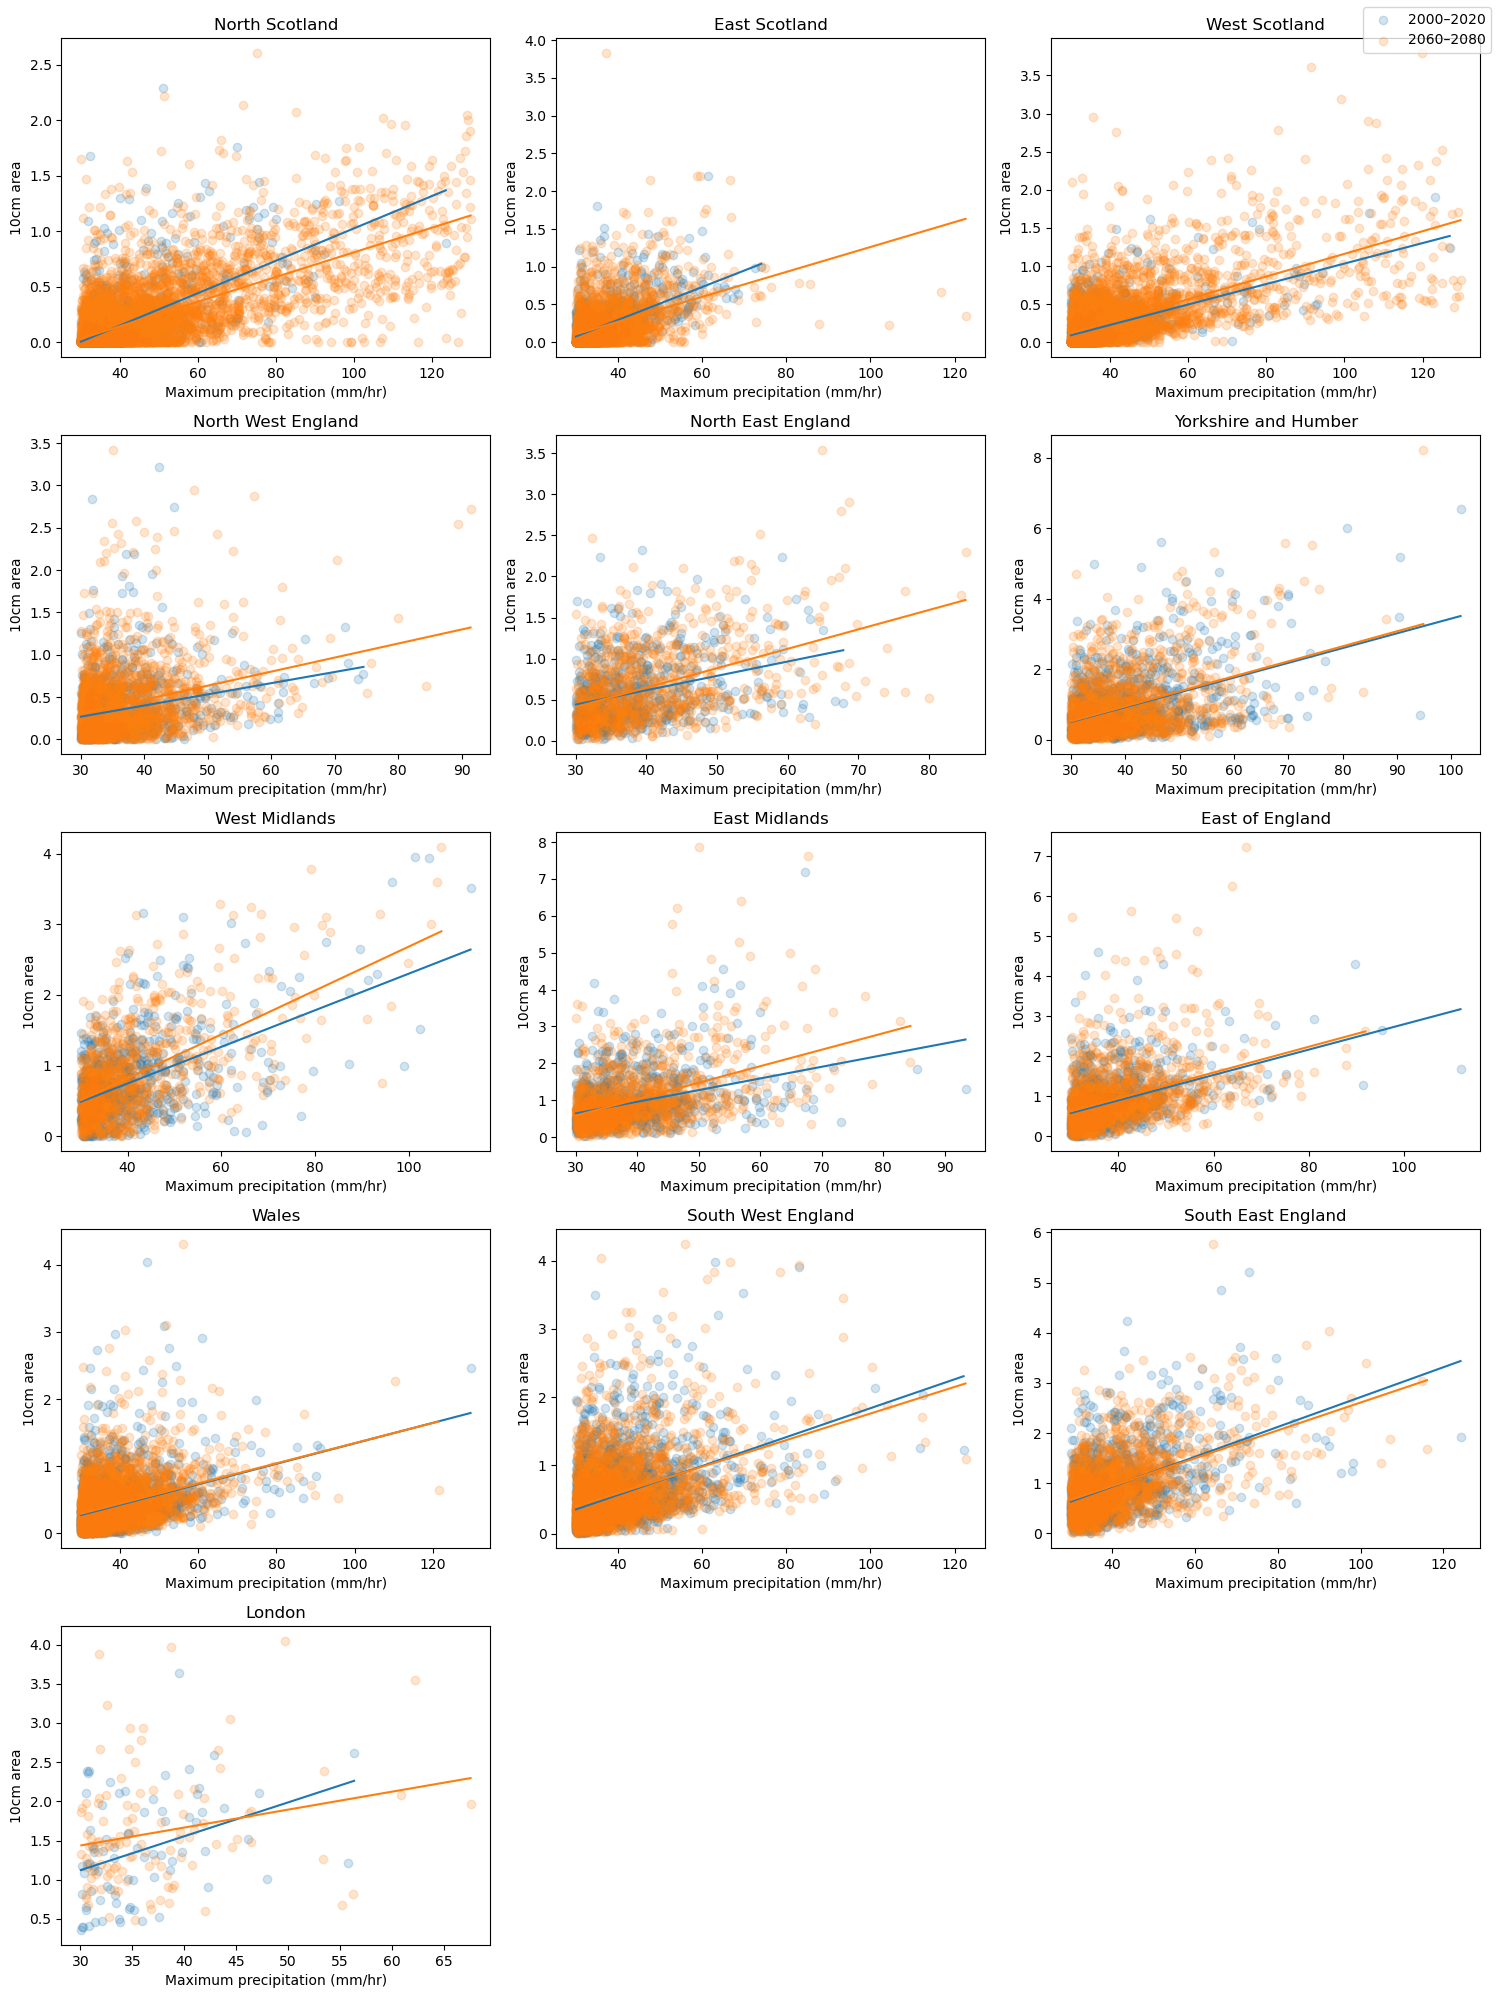

In [17]:
fig, axes = plt.subplots(nrows=int(np.ceil(len(region_order) / 3)),ncols=3, figsize=(15, 4 * int(np.ceil(len(region_order) / 3))))
axes = np.atleast_1d(axes).flatten()

for ax, region in zip(axes, region_order):

    region_df = df_plot[df_plot["geo_region"] == region]

    for period, group in region_df.groupby("period"):

        ax.scatter(group["max_precip"],group["10cm_area"],alpha=0.2,label=period)

        if len(group) > 2:
            slope, intercept, r, p, se = linregress(group["max_precip"],group["10cm_area"])
            x_line = np.linspace(group["max_precip"].min(),group["max_precip"].max(),100)
            ax.plot(x_line,intercept + slope * x_line)

    ax.set_title(region)
    ax.set_xlabel("Maximum precipitation (mm/hr)")
    ax.set_ylabel("10cm area")

# Remove unused axes
for ax in axes[len(region_order):]:
    ax.remove()

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels)

plt.tight_layout()
plt.show()

</div>

<div style="background-color: lightblue; border: 1px solid black; border-radius: 5px; padding: 15px 20px; margin: 10px 0px;">

## Line plots of changes over time to rainfall and flood variables


</div>

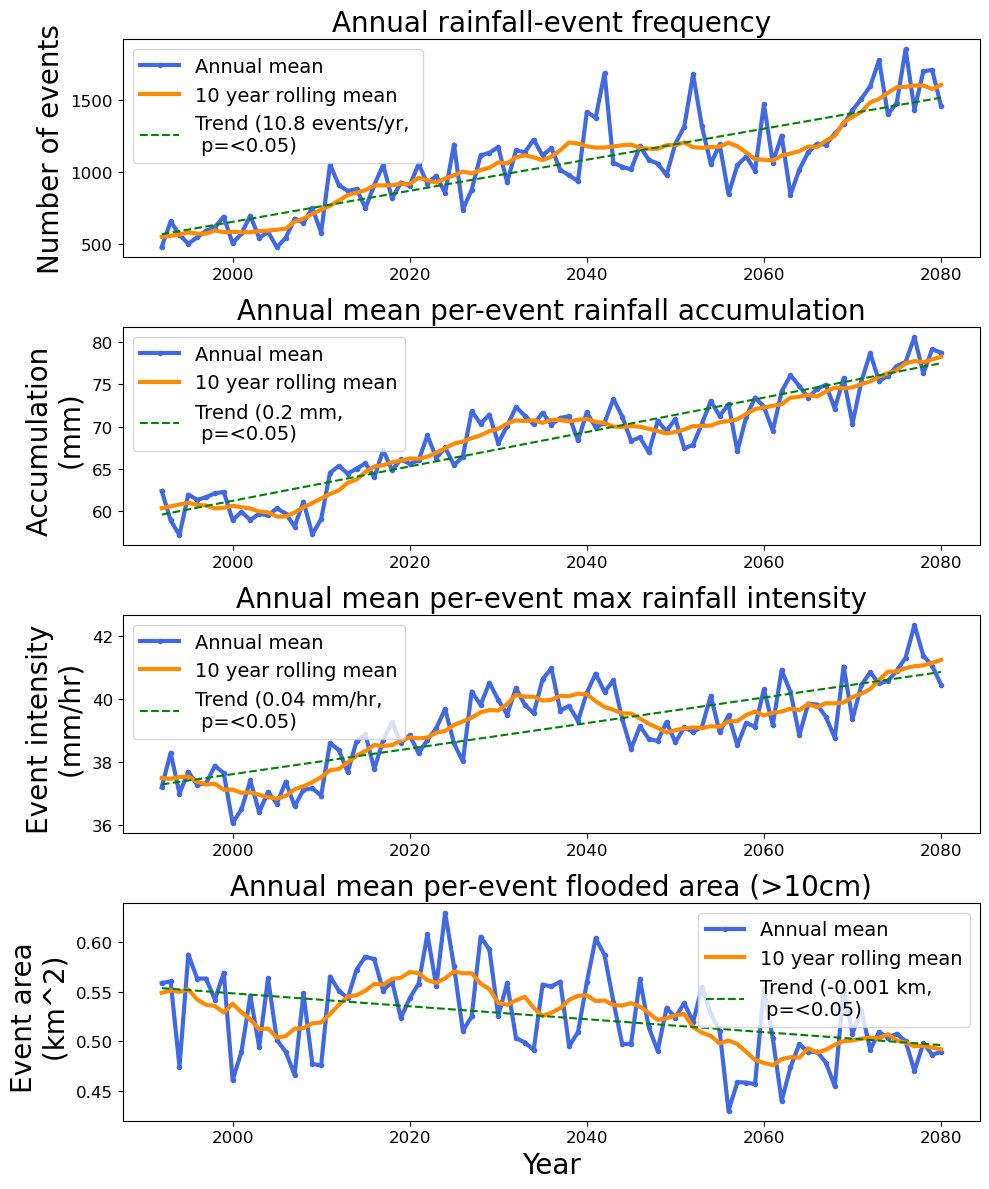

In [18]:
fig, axs = plt.subplots(nrows = 4, figsize=(10, 12), sharex=False)
    
make_subplot(axs[0], annual_counts, "Number of events", "Annual rainfall-event frequency", 1, "events/yr")
make_subplot(axs[1], annual_mean_rainfall_accum, "Accumulation \n (mm)", "Annual mean per-event rainfall accumulation",1, "mm")
make_subplot(axs[2], annual_mean_rainfall_intensity, "Event intensity \n (mm/hr)", "Annual mean per-event max rainfall intensity", 
             2, "mm/hr")
make_subplot(axs[3], annual_mean_flood_severity, "Event area \n (km^2)", "Annual mean per-event flooded area (>10cm)", 3,"km")
axs[3].set_xlabel("Year", fontsize=20)

plt.tight_layout()

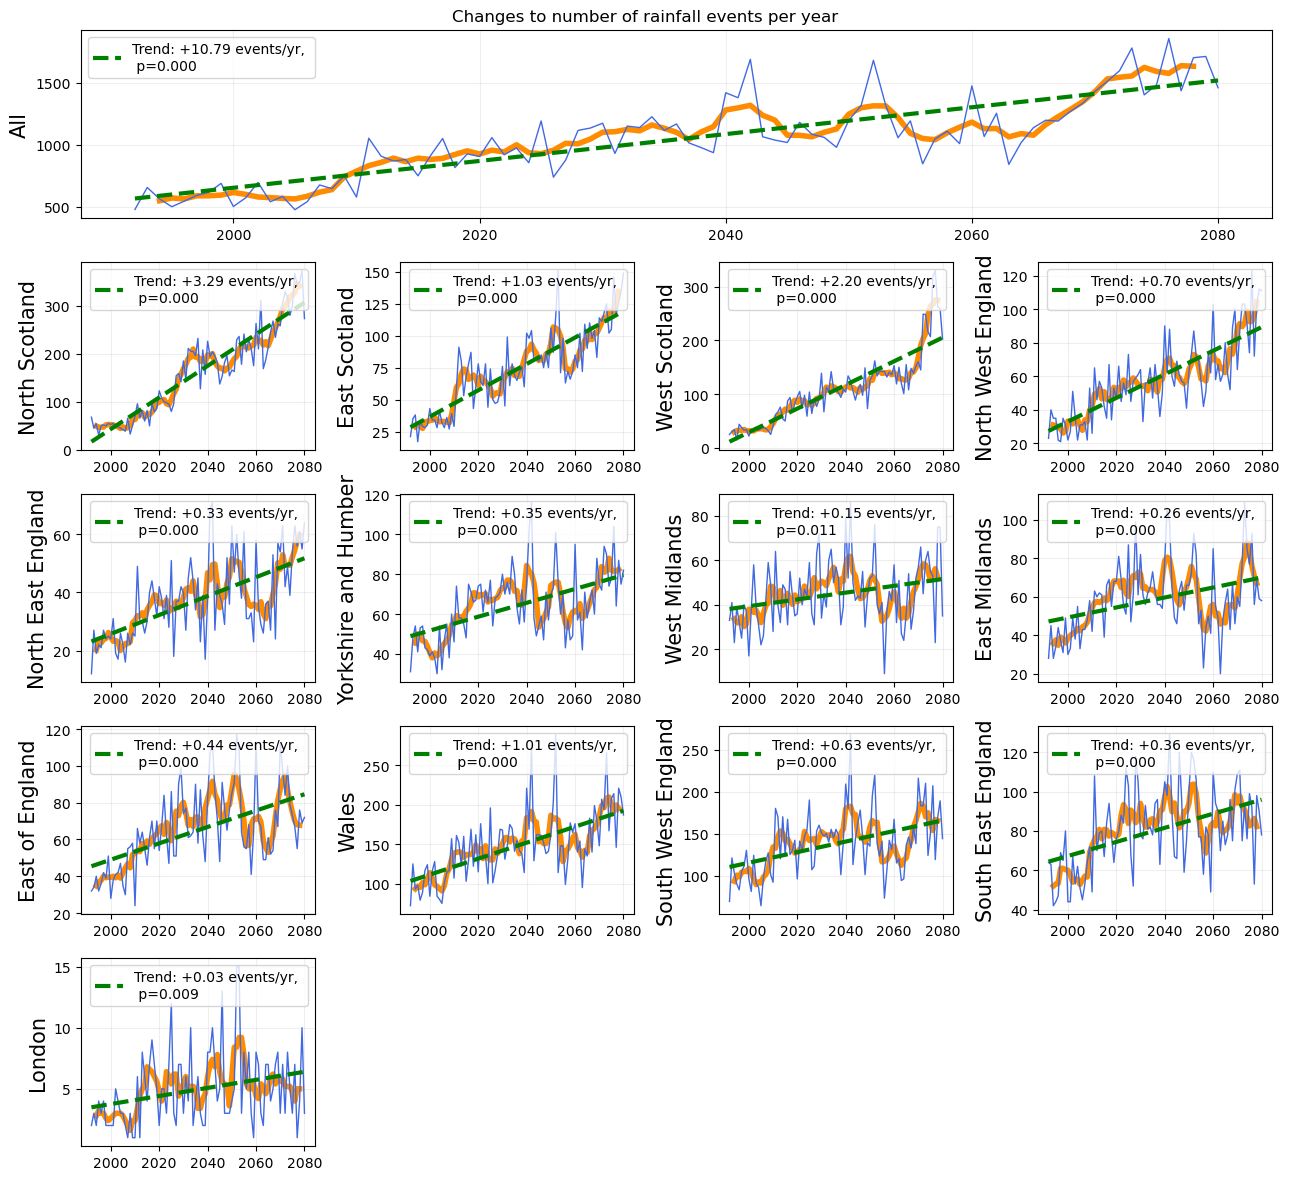

In [19]:
plot_all_with_regions(rainfall_events_all_df, 'count', "Changes to number of rainfall events per year", region_order)

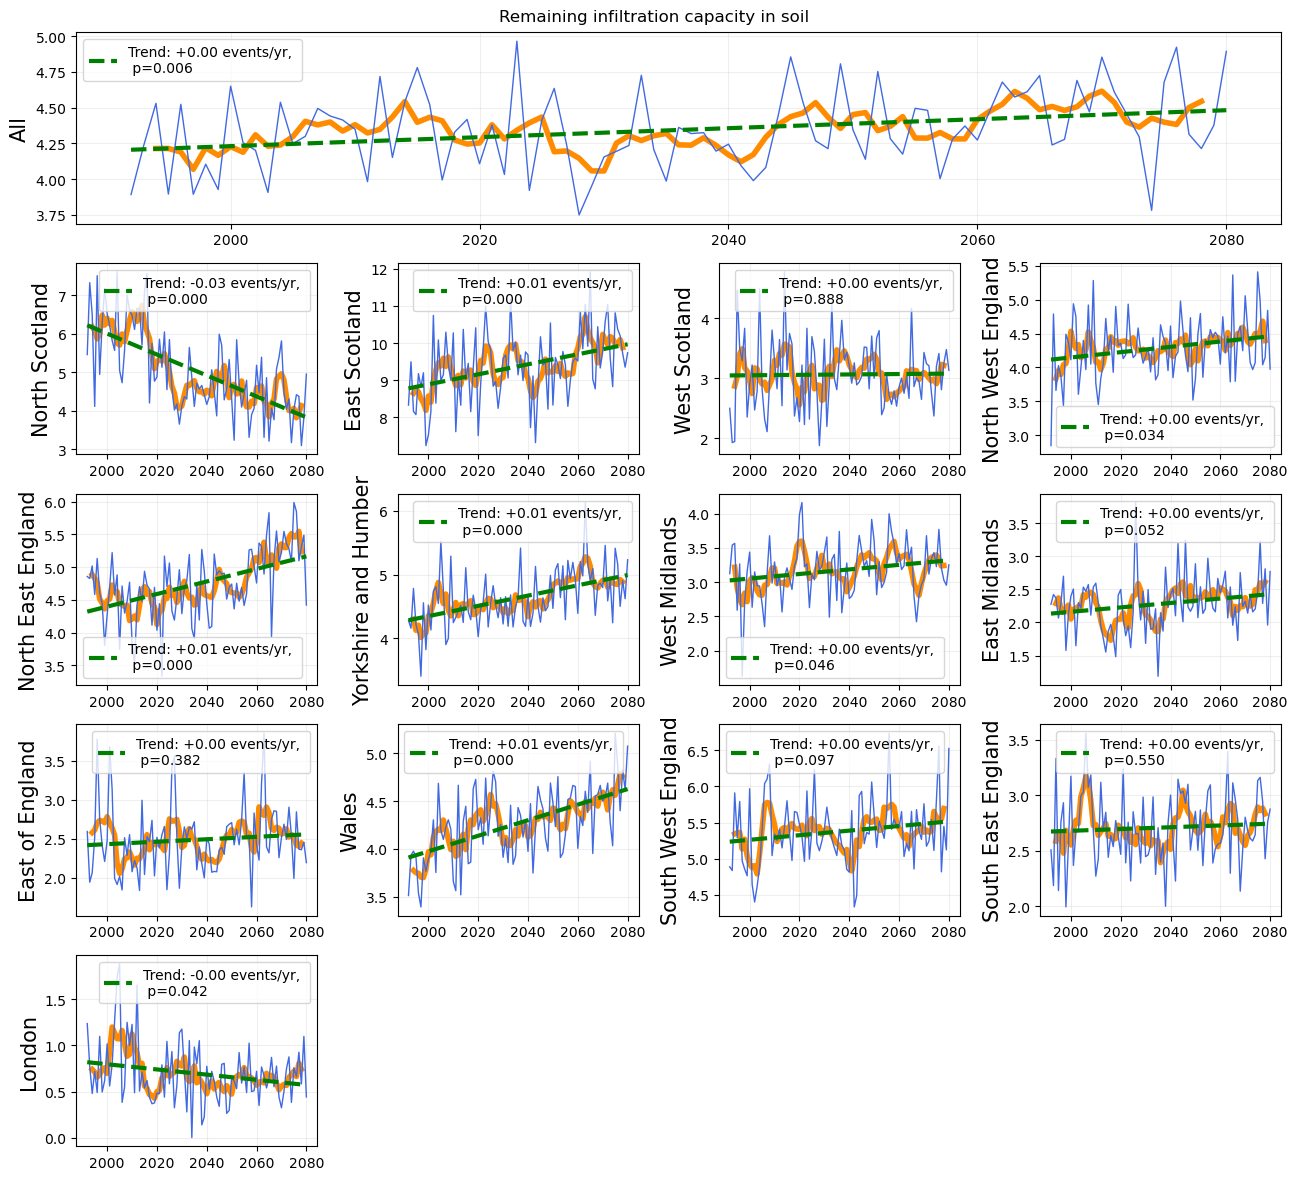

In [20]:
plot_all_with_regions(rainfall_events_all_df, 'fu_at_peak_mm', "Remaining infiltration capacity in soil", region_order)

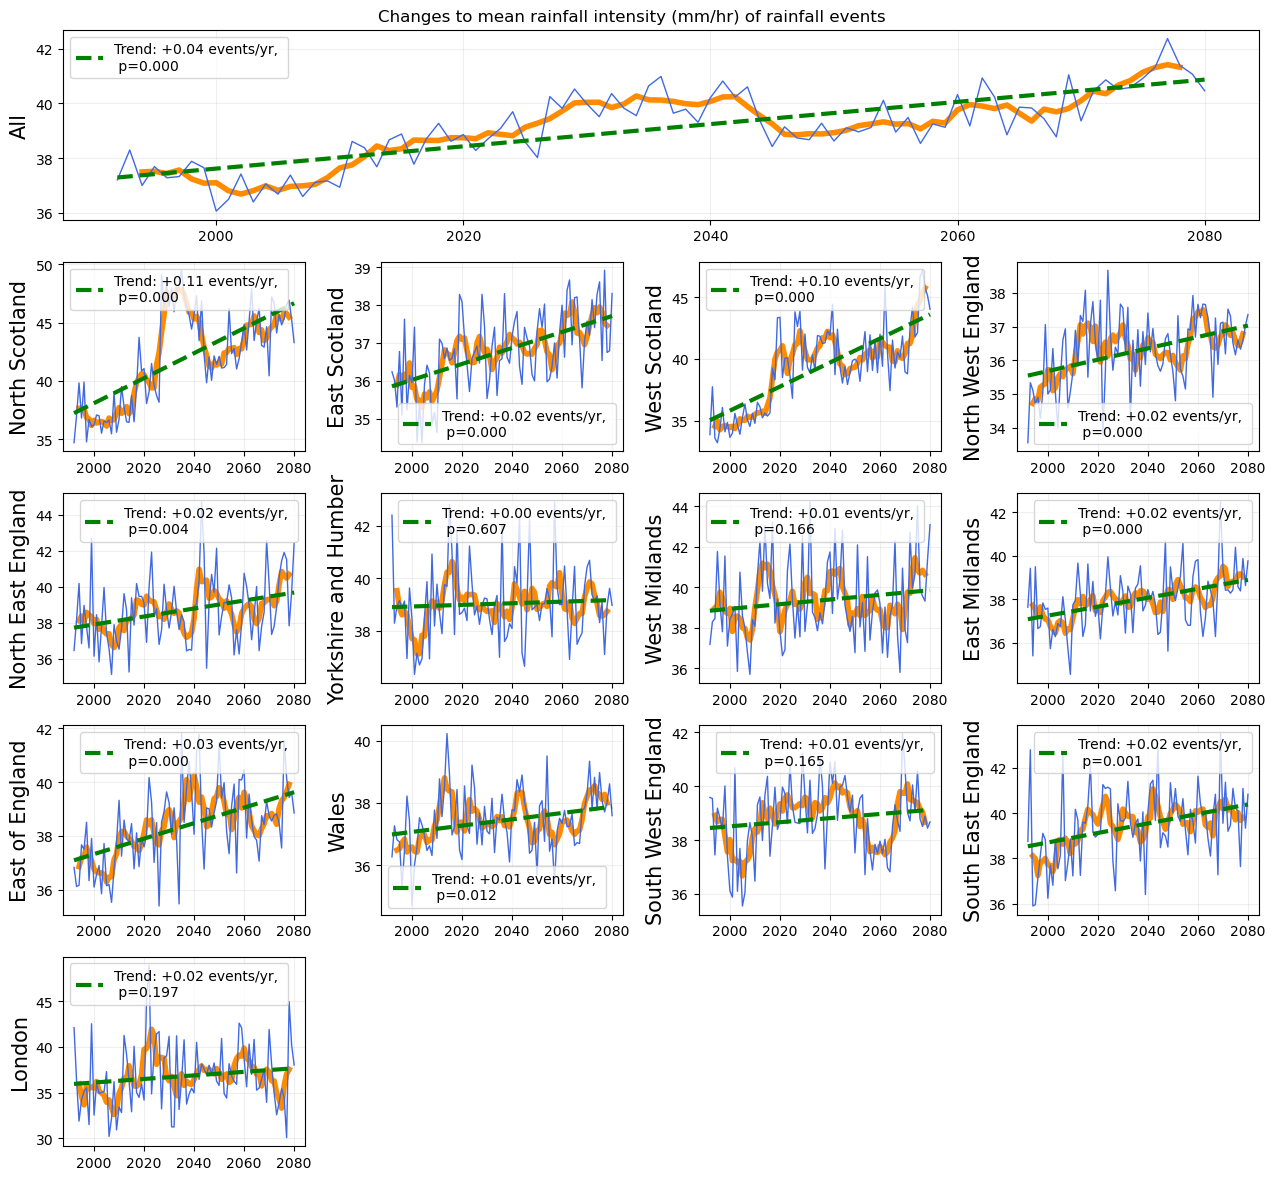

In [21]:
plot_all_with_regions(rainfall_events_all_df, 'max_precip', "Changes to mean rainfall intensity (mm/hr) of rainfall events", region_order)

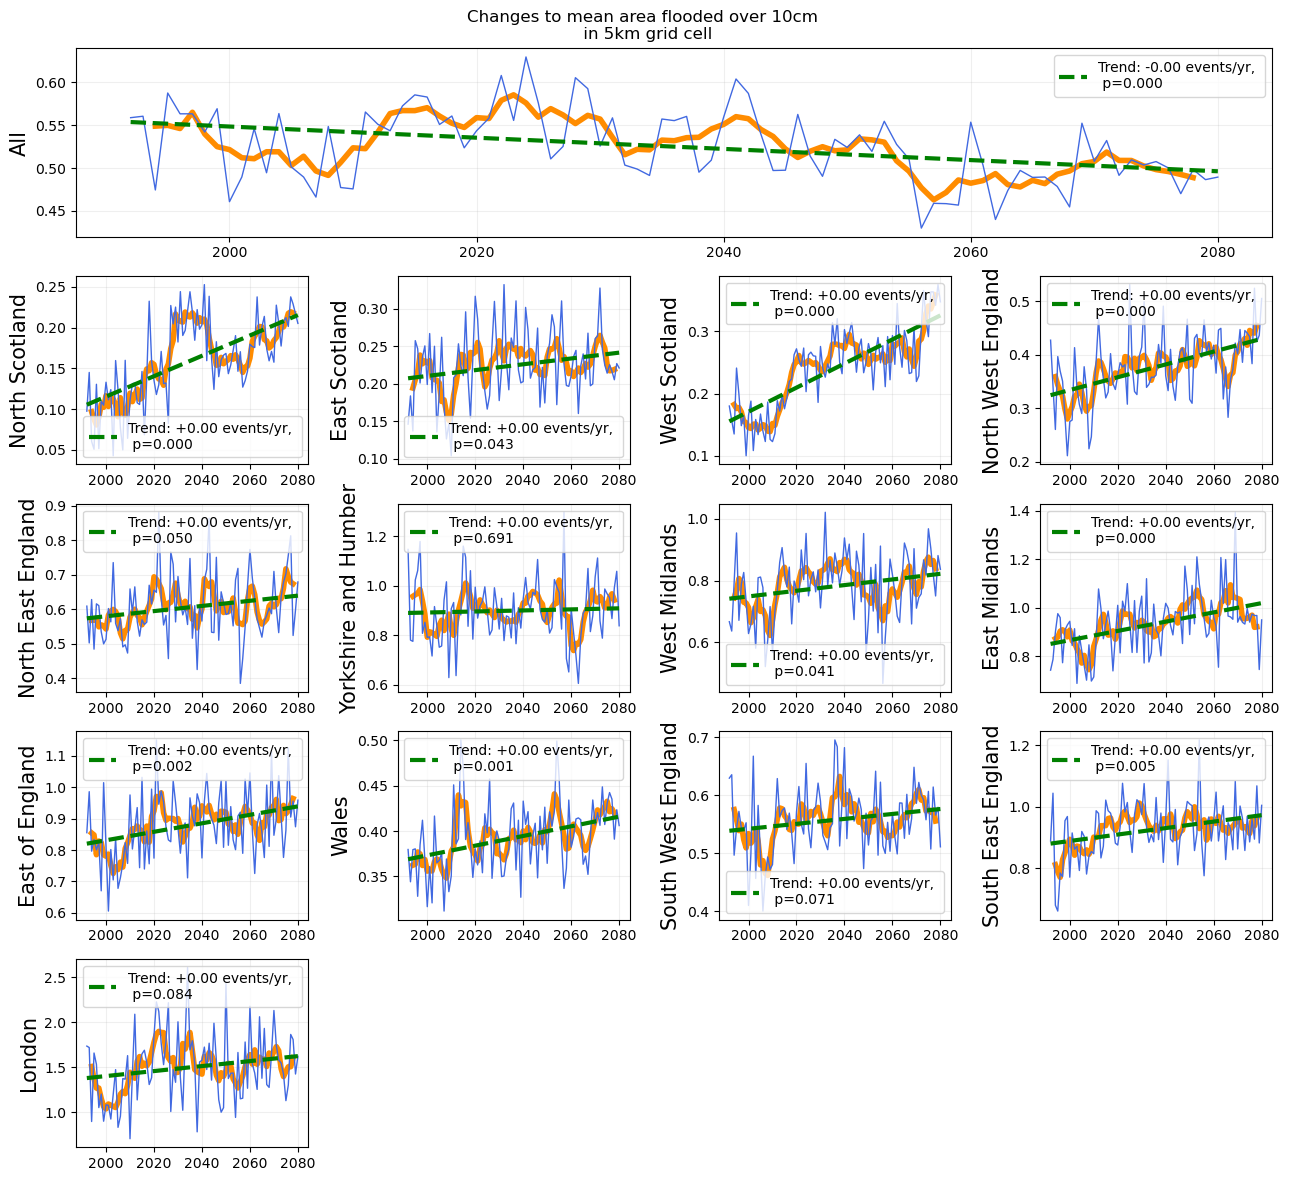

In [22]:
plot_all_with_regions(rainfall_events_all_df, '10cm_area', "Changes to mean area flooded over 10cm \n in 5km grid cell", region_order)

</div>

<div style="background-color: lightblue; border: 1px solid black; border-radius: 5px; padding: 15px 20px; margin: 10px 0px;">

## Changed to flooded area in future climate


</div>

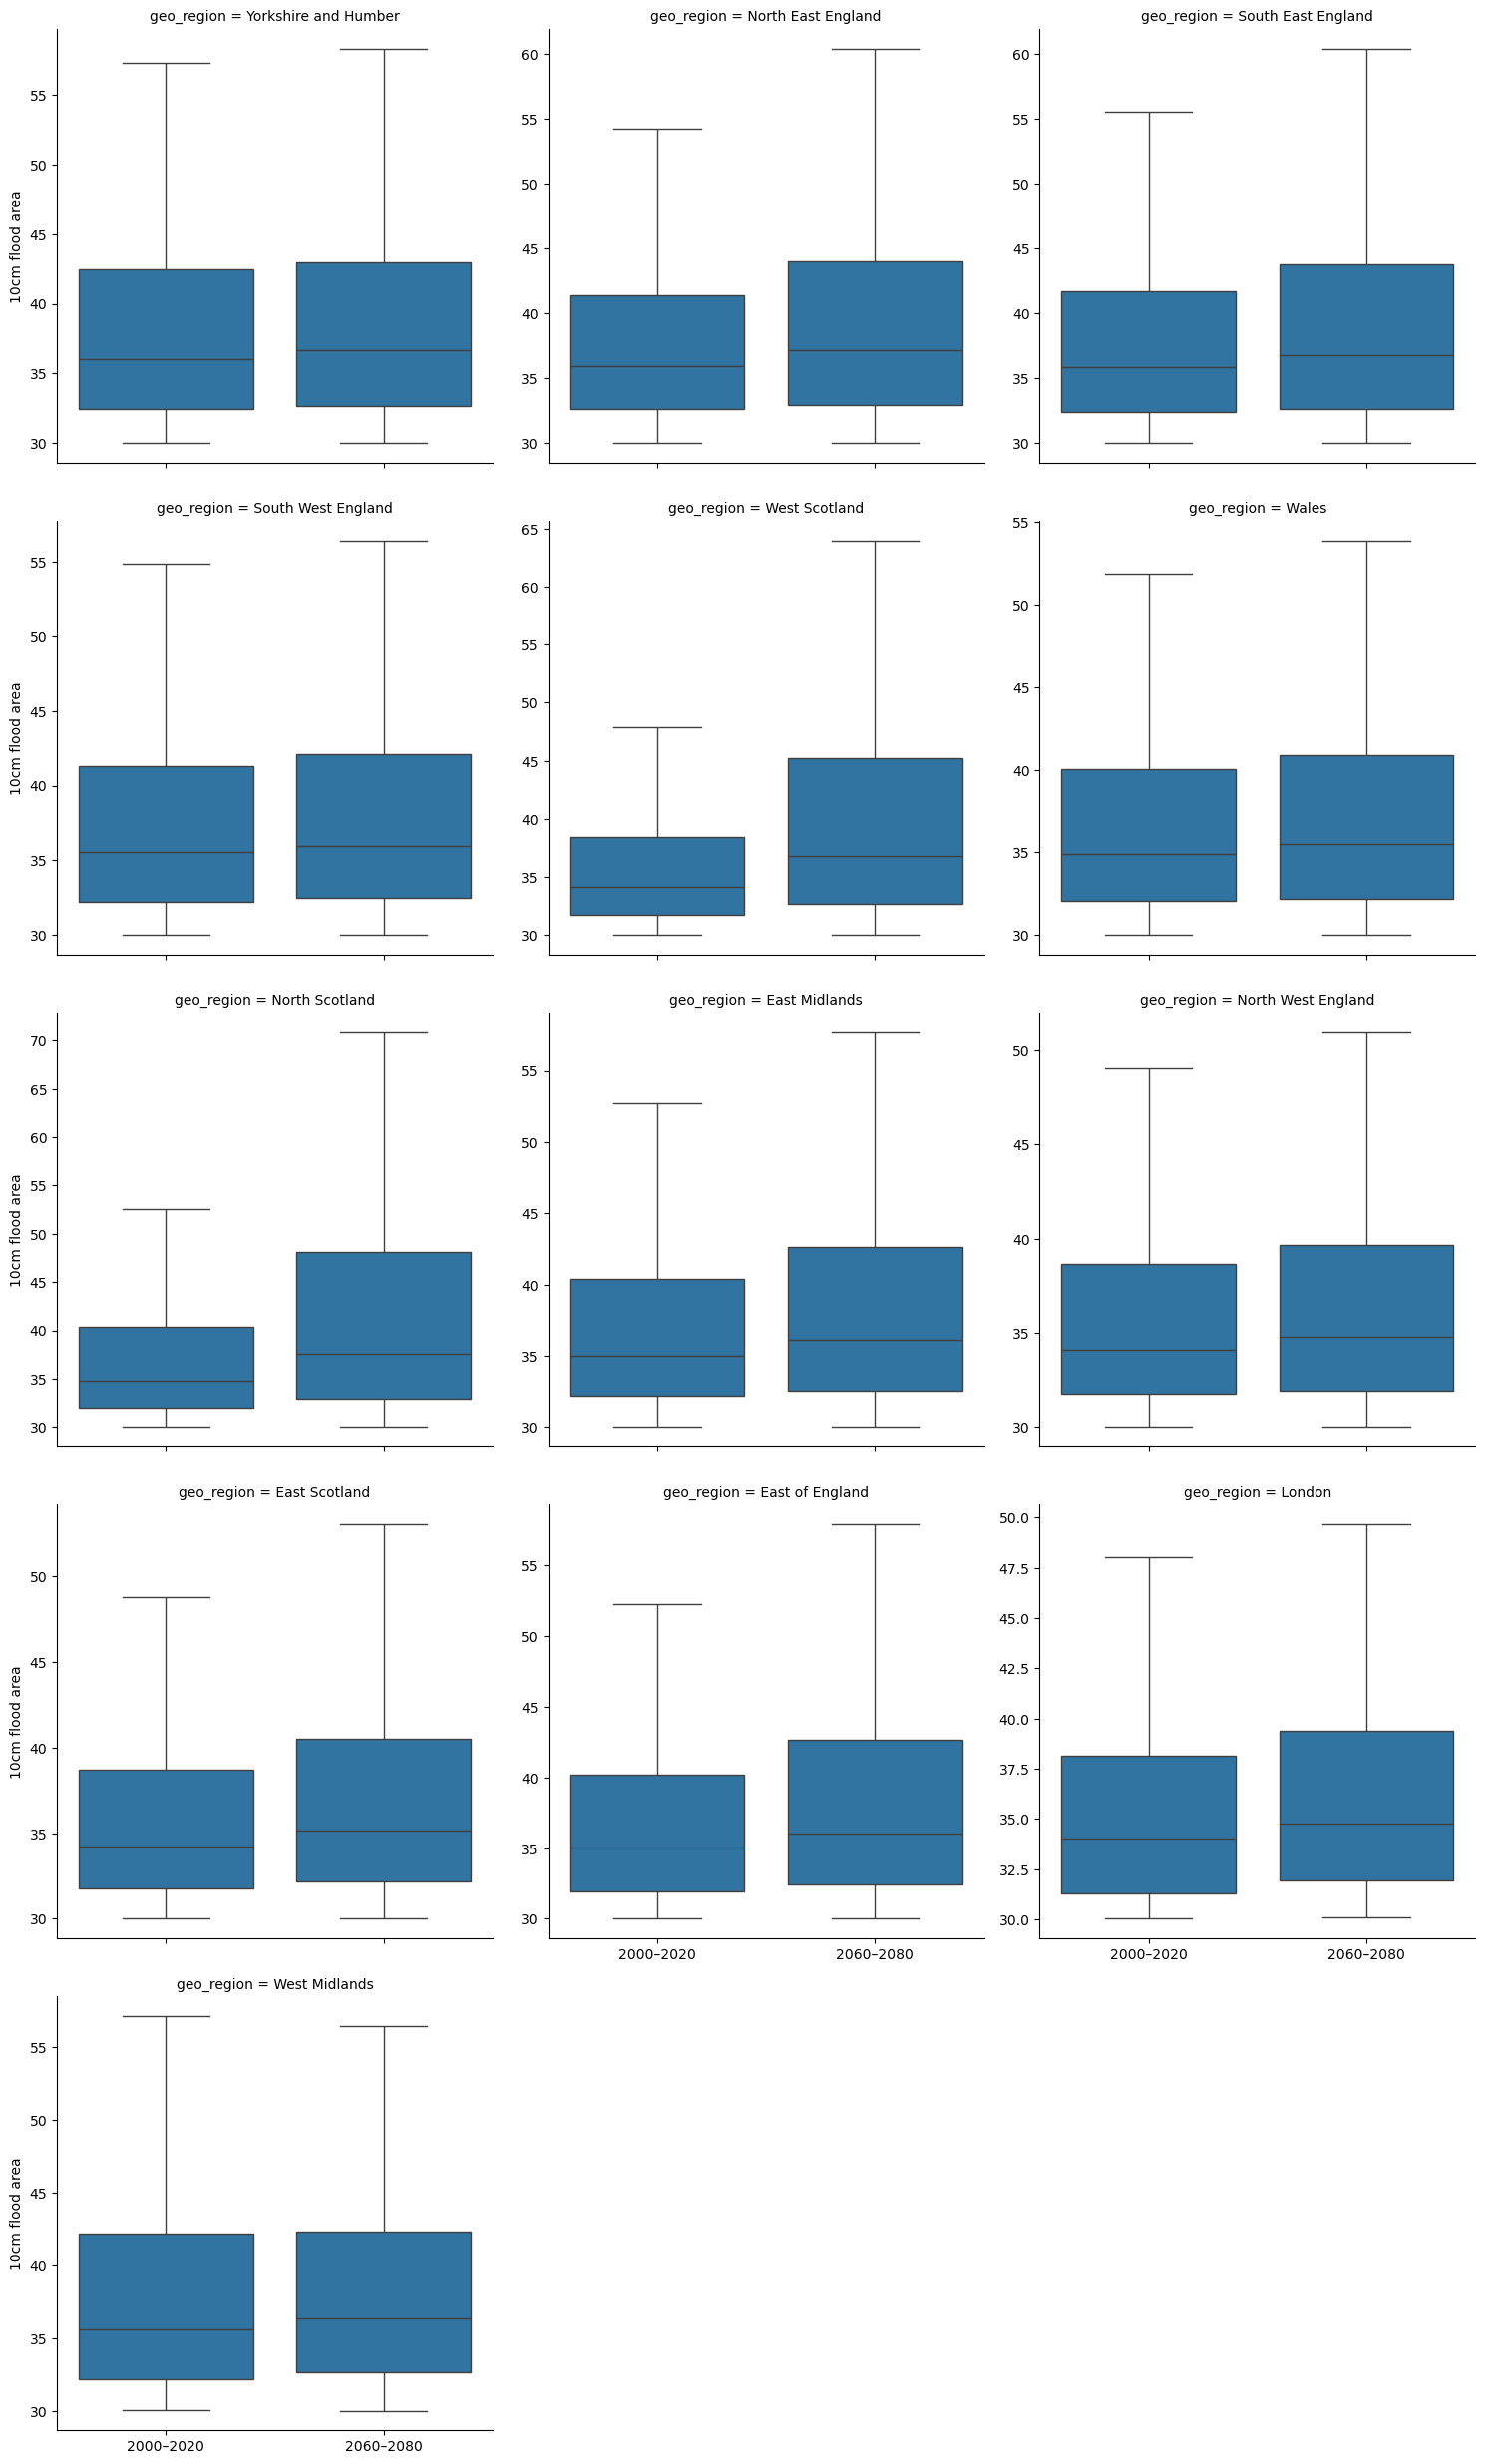

In [23]:
g = sns.catplot(data=df_plot,x="period",y="max_precip",col="geo_region",col_wrap=3,kind="box",sharey=False,showfliers=False)

g.set_axis_labels("", "10cm flood area")

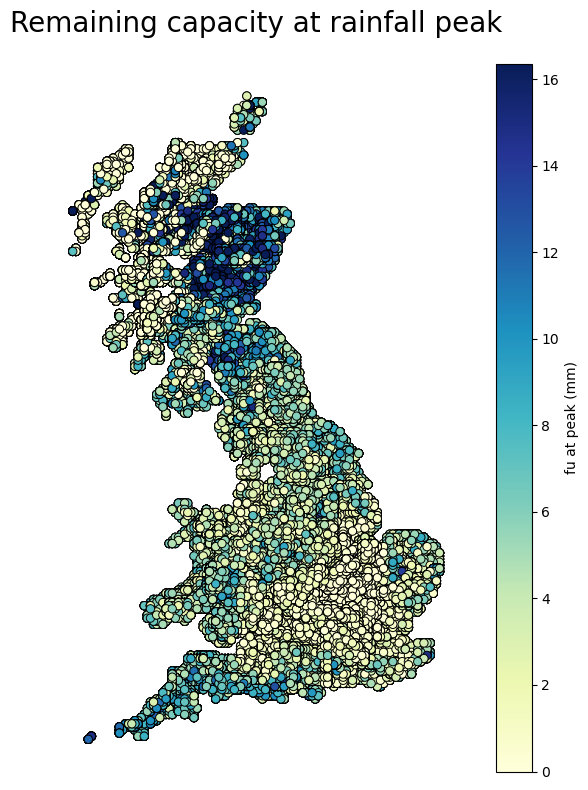

In [32]:
vmin = rainfall_events_all_df["fu_at_peak_mm"].quantile(0.02)
vmax = rainfall_events_all_df["fu_at_peak_mm"].quantile(0.98)

fig, ax_map = plt.subplots(figsize=(8, 8))

rainfall_events_all_df.plot(ax=ax_map,column="fu_at_peak_mm",cmap="YlGnBu",vmin=vmin,vmax=vmax,edgecolor="black",
                            linewidth=0.7,legend=True,legend_kwds={"label": "fu at peak (mm)"})

ax_map.set_title("Remaining capacity at rainfall peak", fontsize=20, pad=12)
ax_map.set_axis_off()

fig.tight_layout()
plt.show()

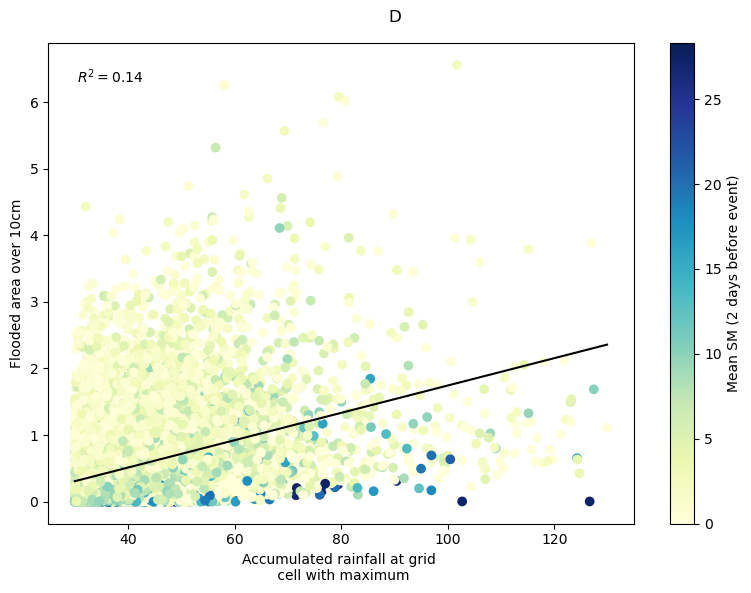

In [49]:
from Functions_AnalyseResults import partial_r2_for_catchment, plot_with_best_fit_line

rainfall_events =rainfall_events_all_df[rainfall_events_all_df['length'] < 15] 
fig, ax = plt.subplots(figsize=(8,6))

plotting_dict1 = {('max_precip', '10cm_area'): ('Accumulated rainfall at grid \n cell with maximum','Flooded area over 10cm')}

for (variable1, variable2), (var_name1, var_name2) in plotting_dict1.items():
    sc = plot_with_best_fit_line(rainfall_events, ax, variable1, variable2, var_name1, var_name2, '')
    cbar = plt.colorbar(sc, ax=ax)
    cbar.set_label('Mean SM (2 days before event)')
        
fig.suptitle('D')
fig.tight_layout()